# Fire locations on $S^2$

Explore the official Fire dataset before building the RFM training pipeline.

## 1. Imports and data path

In [63]:
import pandas as pd
import torch

## 2. Raw shape and first rows

In [64]:
fire = pd.read_csv("../data/fire.csv")

In [65]:
fire.shape

(12809, 2)

In [66]:
fire.head()

,LATITUDE,LONGITUDE
0,-25.088,152.358
1,-30.087,150.998
2,-6.370,155.393
3,-42.563,147.325
4,-15.600,-39.341


## 3. Missing and non-finite values

In [67]:
fire.isnull().mean()

LATITUDE     0.0
LONGITUDE    0.0
dtype: float64

## 4. Latitude and longitude ranges

In [68]:
fire.max()

LATITUDE      59.729
LONGITUDE    171.977
dtype: float64

In [69]:
fire.min()

LATITUDE     -46.259
LONGITUDE   -123.438
dtype: float64

In [70]:
fire.max()

LATITUDE      59.729
LONGITUDE    171.977
dtype: float64

## 5. Geographic scatter

<Axes: xlabel='LONGITUDE', ylabel='LATITUDE'>

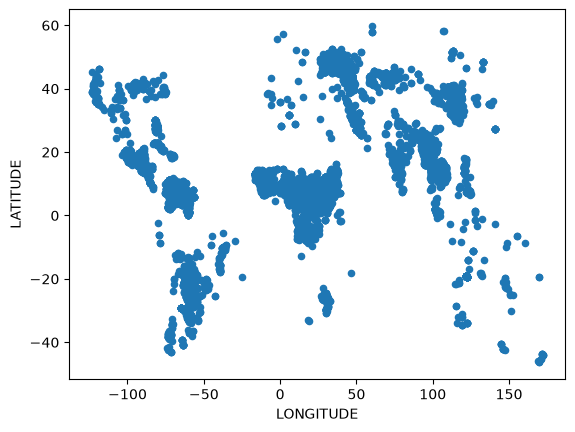

In [71]:
fire.plot.scatter("LONGITUDE", "LATITUDE")

## 6. Convert latitude/longitude to Cartesian coordinates

In [72]:
latitude = torch.tensor(fire['LATITUDE'].values)
longitude = torch.tensor(fire['LONGITUDE'].values)
phi = torch.pi/180 * latitude
z = torch.sin(phi).reshape(-1,1)
theta = torch.pi / 180 * longitude
x = torch.sqrt(1-torch.square(z)) * torch.cos(theta).reshape(-1,1)
y = torch.sqrt(1-torch.square(z)) * torch.sin(theta).reshape(-1,1)


## 7. Verify unit norms

In [73]:
xyz = torch.concat([x,y,z], dim=1)
xyz_norm = torch.linalg.vector_norm(xyz, ord=2, dim=-1)
tol = 1e-4
assert torch.all(torch.abs(xyz_norm - 1)<=tol)

In [74]:
xyz_norm.min()

tensor(1.0000, dtype=torch.float64)

In [75]:
xyz_norm.max()

tensor(1.0000, dtype=torch.float64)

In [76]:
xyz.shape

torch.Size([12809, 3])

In [77]:
xyz.dtype

torch.float64

## 8. Verify seeded split counts

In [78]:
generator = torch.Generator().manual_seed(42)

In [79]:
n = len(xyz)


In [80]:
indices = torch.randperm(n, generator=generator)

In [81]:
n_train = int(0.8*n)
n_val = int(0.1*n)
n_test = n - n_train - n_val

In [82]:
train, val, test = torch.split(xyz[indices], [n_train, n_val, n_test])

In [83]:
train.shape, val.shape, test.shape

(torch.Size([10247, 3]), torch.Size([1280, 3]), torch.Size([1282, 3]))